# 퀀트 트레이딩 스터디

## 1단계: yfinance로 주가 데이터 수집

In [7]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [8]:
# 삼성전자 (005930.KS) 최근 1년 데이터
ticker = '005930.KS'
df = yf.download(ticker, period='1y')
df.columns = df.columns.droplevel(1)
df.head(10)

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2025-06-18,58763.558594,58763.558594,56896.489006,56994.755827,17620705
2025-06-19,58173.953125,59549.688503,57977.419500,59451.421690,16876278
2025-06-20,58468.757812,58763.558272,58075.690533,58370.490993,18072251
2025-06-23,56994.757812,57486.091932,56601.690517,57387.825108,16551694
2025-06-24,59451.425781,59549.692601,58272.223948,58370.490767,23737899
2025-06-25,60237.562500,60532.362969,59254.894270,60434.096146,23933612
2025-06-26,59156.625000,60237.560008,58861.824543,60237.560008,19402300
2025-06-27,60112.695312,60903.651830,59321.738795,59420.608360,17340470
2025-06-30,59124.000000,60508.173913,59124.000000,60508.173913,17110294


In [9]:
# 데이터 구조 확인
print(f'기간: {df.index[0].date()} ~ {df.index[-1].date()}')
print(f'데이터 수: {len(df)}일')
print(f'\n컬럼: {list(df.columns)}')
df.describe()

기간: 2025-06-18 ~ 2026-06-18
데이터 수: 244일

컬럼: ['Close', 'High', 'Low', 'Open', 'Volume']


Price,Close,High,Low,Open,Volume
count,244.000000,244.000000,244.000000,244.000000,2.440000e+02
mean,143787.216237,146455.340909,140652.508450,143274.487433,2.493690e+07
std,78966.831890,81220.942151,76183.018917,78345.153108,1.069543e+07
min,56994.757812,57486.091932,56601.690517,56994.755827,1.191000e+03
25%,74053.302734,74349.909618,72842.150584,73410.650587,1.798498e+07
50%,107652.781250,109142.440048,106312.085464,108298.298480,2.276137e+07
75%,190081.570312,195694.950409,188310.233872,192775.987997,3.053935e+07
max,360500.000000,370000.000000,348000.000000,360500.000000,8.942795e+07


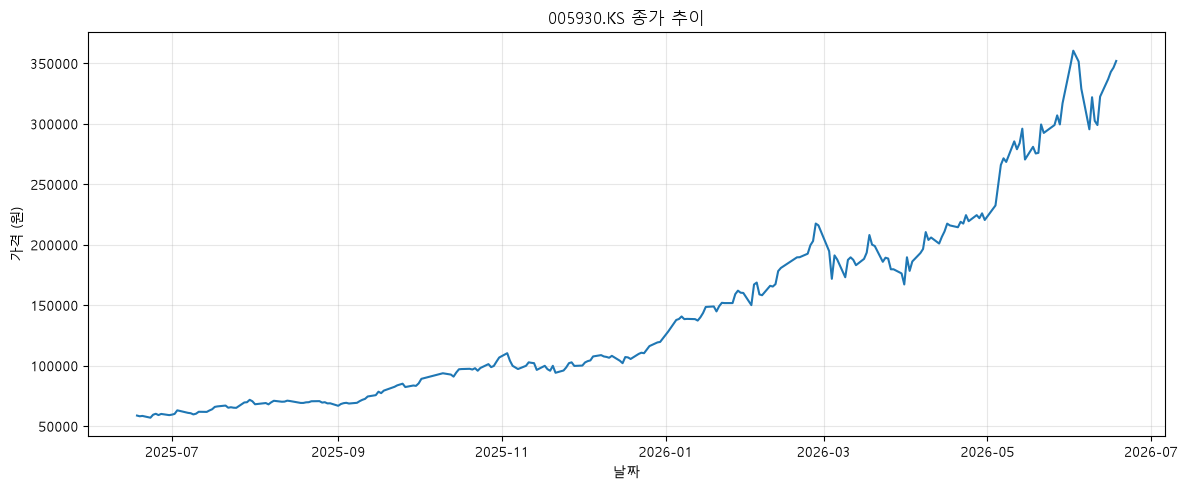

In [10]:
# 종가 차트
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Close'])
plt.title(f'{ticker} 종가 추이')
plt.xlabel('날짜')
plt.ylabel('가격 (원)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

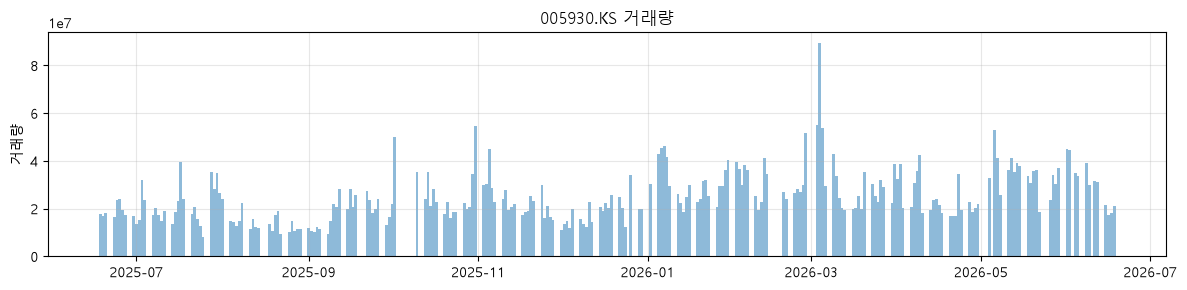

In [11]:
# 거래량 차트
plt.figure(figsize=(12, 3))
plt.bar(df.index, df['Volume'], width=1, alpha=0.5)
plt.title(f'{ticker} 거래량')
plt.ylabel('거래량')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2단계: 기술지표 계산 (이동평균, RSI, MACD)

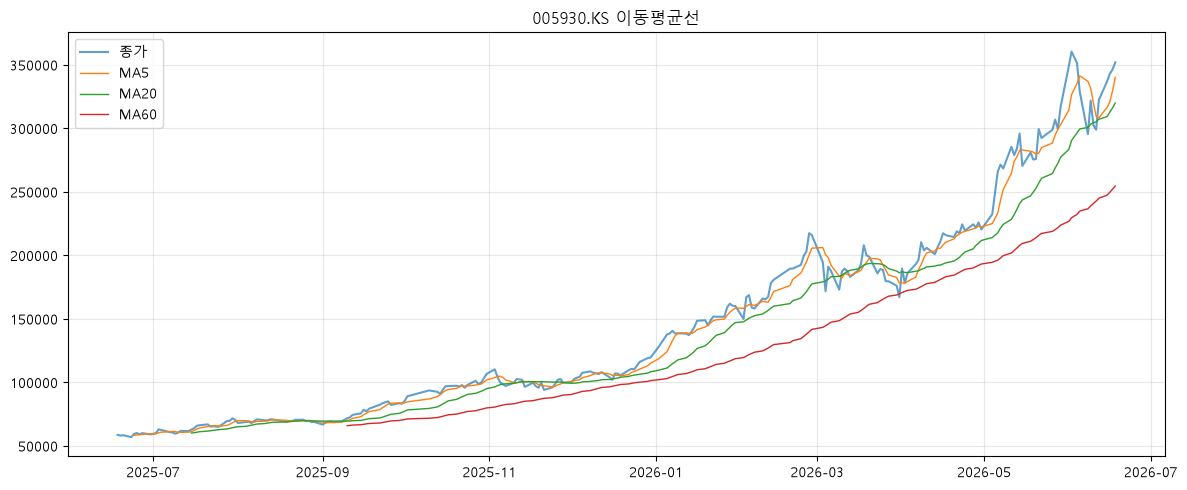

In [12]:
# 이동평균선 (5일, 20일, 60일)
df['MA5'] = df['Close'].rolling(window=5).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA60'] = df['Close'].rolling(window=60).mean()

plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Close'], label='종가', alpha=0.7)
plt.plot(df.index, df['MA5'], label='MA5', linewidth=1)
plt.plot(df.index, df['MA20'], label='MA20', linewidth=1)
plt.plot(df.index, df['MA60'], label='MA60', linewidth=1)
plt.title(f'{ticker} 이동평균선')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

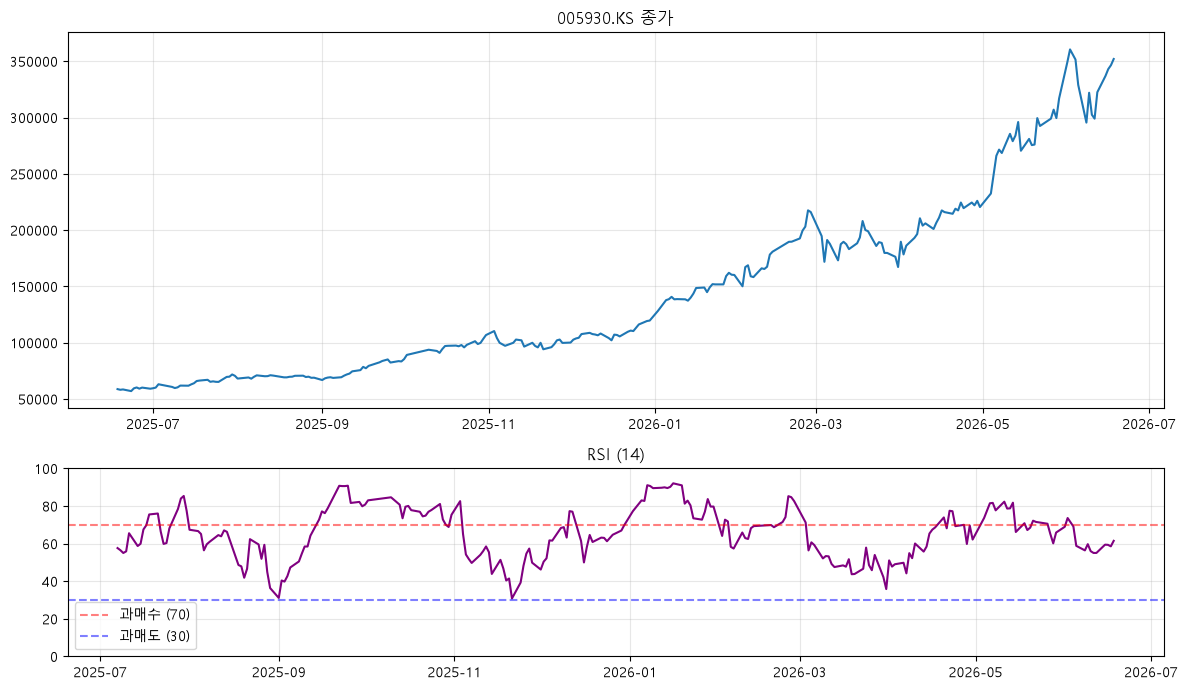

In [13]:
# RSI (14일)
delta = df['Close'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss
df['RSI'] = 100 - (100 / (1 + rs))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(df.index, df['Close'])
ax1.set_title(f'{ticker} 종가')
ax1.grid(True, alpha=0.3)

ax2.plot(df.index, df['RSI'], color='purple')
ax2.axhline(y=70, color='r', linestyle='--', alpha=0.5, label='과매수 (70)')
ax2.axhline(y=30, color='b', linestyle='--', alpha=0.5, label='과매도 (30)')
ax2.set_title('RSI (14)')
ax2.set_ylim(0, 100)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

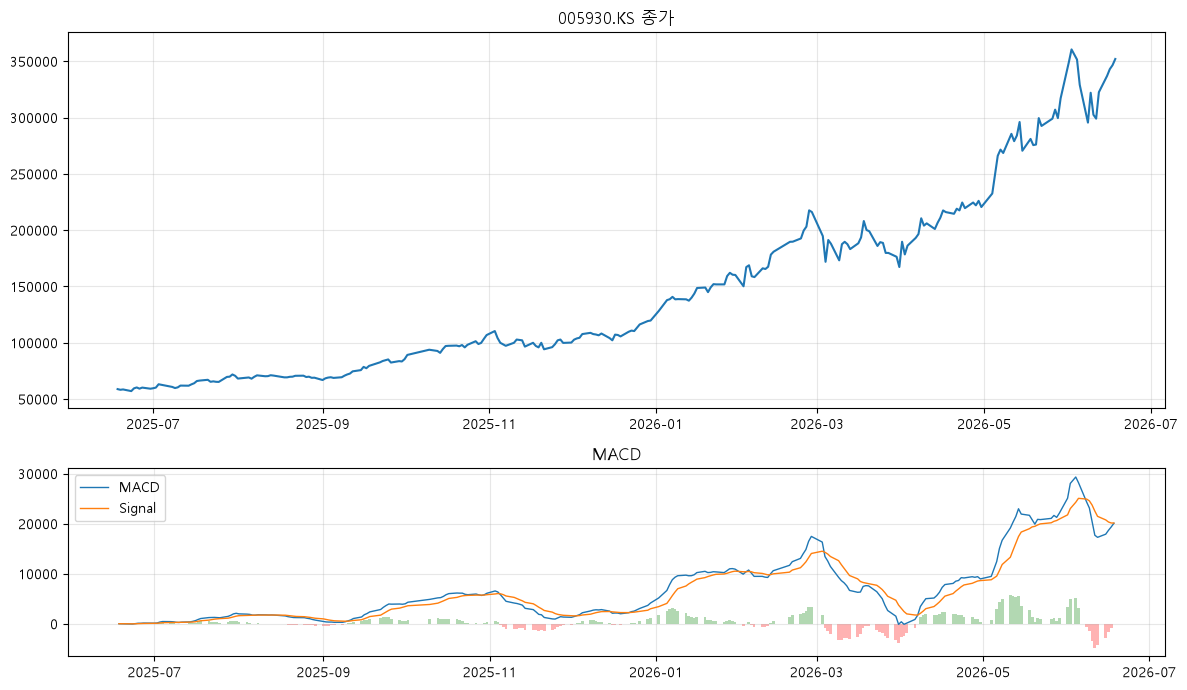

In [14]:
# MACD (12, 26, 9)
df['EMA12'] = df['Close'].ewm(span=12).mean()
df['EMA26'] = df['Close'].ewm(span=26).mean()
df['MACD'] = df['EMA12'] - df['EMA26']
df['Signal'] = df['MACD'].ewm(span=9).mean()
df['Histogram'] = df['MACD'] - df['Signal']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(df.index, df['Close'])
ax1.set_title(f'{ticker} 종가')
ax1.grid(True, alpha=0.3)

ax2.plot(df.index, df['MACD'], label='MACD', linewidth=1)
ax2.plot(df.index, df['Signal'], label='Signal', linewidth=1)
colors = ['green' if v >= 0 else 'red' for v in df['Histogram']]
ax2.bar(df.index, df['Histogram'], color=colors, alpha=0.3, width=1)
ax2.set_title('MACD')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3단계: 매매 전략 설계 (골든크로스/데드크로스)

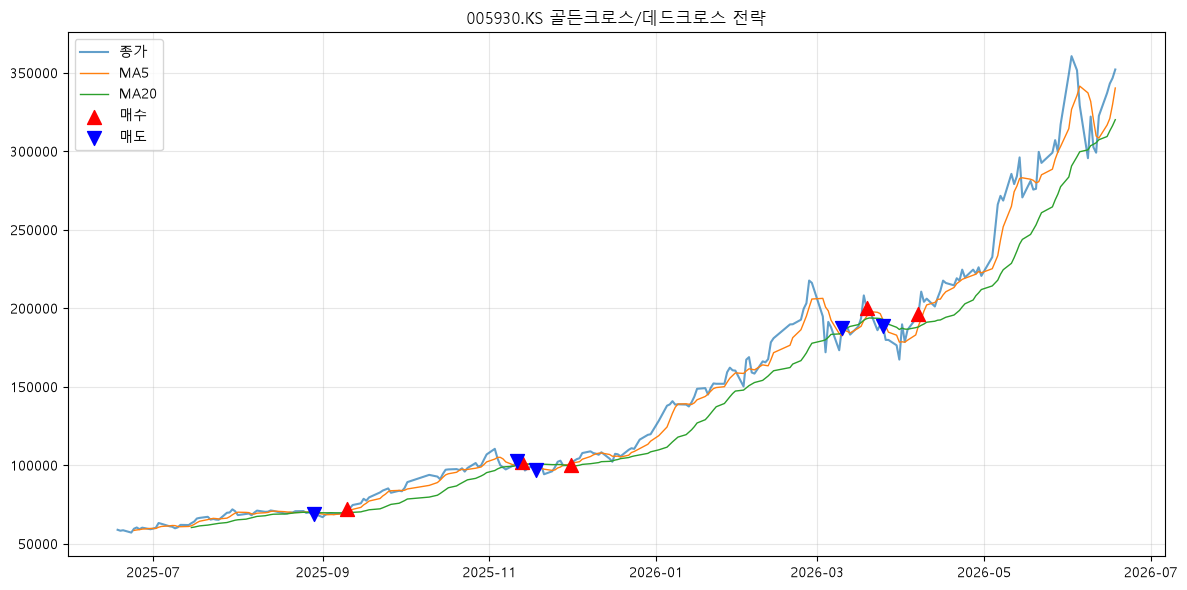

매수 신호: 5회
매도 신호: 5회


In [15]:
# 골든크로스: MA5가 MA20을 상향돌파 -> 매수
# 데드크로스: MA5가 MA20을 하향돌파 -> 매도

df['Position'] = 0
df.loc[df['MA5'] > df['MA20'], 'Position'] = 1   # 매수 구간
df.loc[df['MA5'] <= df['MA20'], 'Position'] = -1  # 매도 구간
df['Signal_Cross'] = df['Position'].diff()

buy_signals = df[df['Signal_Cross'] == 2]   # -1 -> 1 (골든크로스)
sell_signals = df[df['Signal_Cross'] == -2]  # 1 -> -1 (데드크로스)

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='종가', alpha=0.7)
plt.plot(df.index, df['MA5'], label='MA5', linewidth=1)
plt.plot(df.index, df['MA20'], label='MA20', linewidth=1)
plt.scatter(buy_signals.index, buy_signals['Close'], marker='^', color='red', s=100, label='매수', zorder=5)
plt.scatter(sell_signals.index, sell_signals['Close'], marker='v', color='blue', s=100, label='매도', zorder=5)
plt.title(f'{ticker} 골든크로스/데드크로스 전략')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'매수 신호: {len(buy_signals)}회')
print(f'매도 신호: {len(sell_signals)}회')

## 4단계: 백테스팅

In [16]:
# 백테스팅: 초기 자본금 1000만원
initial_capital = 10_000_000
capital = initial_capital
shares = 0
trades = []

for i in range(len(df)):
    price = float(df['Close'].iloc[i])
    
    if df['Signal_Cross'].iloc[i] == 2 and shares == 0:
        shares = capital // price
        capital -= shares * price
        trades.append({'날짜': df.index[i].date(), '유형': '매수', '가격': price, '수량': shares})
    
    elif df['Signal_Cross'].iloc[i] == -2 and shares > 0:
        capital += shares * price
        trades.append({'날짜': df.index[i].date(), '유형': '매도', '가격': price, '수량': shares, '잔고': capital})
        shares = 0

# 마지막에 보유 중이면 현재가로 청산
if shares > 0:
    last_price = float(df['Close'].iloc[-1])
    capital += shares * last_price
    trades.append({'날짜': df.index[-1].date(), '유형': '청산', '가격': last_price, '수량': shares, '잔고': capital})
    shares = 0

final_capital = capital
trade_df = pd.DataFrame(trades)
trade_df

,날짜,유형,가격,수량,잔고
0,2025-09-10,매수,71779.304688,139.0,NaN
1,2025-11-11,매도,102786.554688,139.0,1.431001e+07
2,2025-11-13,매수,102091.382812,140.0,NaN
3,2025-11-18,매도,97125.851562,140.0,1.361483e+07
4,2025-12-01,매수,100105.171875,136.0,NaN
5,2026-03-10,매도,187511.890625,136.0,2.550215e+07
6,2026-03-19,매수,200085.859375,127.0,NaN
7,2026-03-25,매도,188609.609375,127.0,2.404466e+07
8,2026-04-07,매수,196500.000000,122.0,NaN
9,2026-06-18,청산,352000.000000,122.0,4.301566e+07


## 5단계: 성과 지표 분석

In [17]:
# 전략 수익률
strategy_return = (final_capital - initial_capital) / initial_capital * 100

# 단순 보유(Buy & Hold) 수익률
first_price = float(df['Close'].iloc[0])
last_price = float(df['Close'].iloc[-1])
bnh_return = (last_price - first_price) / first_price * 100

# 일별 수익률로 샤프비율 계산
df['Daily_Return'] = df['Close'].pct_change()
sharpe_ratio = df['Daily_Return'].mean() / df['Daily_Return'].std() * (252 ** 0.5)

# MDD (최대 낙폭)
df['Cummax'] = df['Close'].cummax()
df['Drawdown'] = (df['Close'] - df['Cummax']) / df['Cummax'] * 100
mdd = df['Drawdown'].min()

print('=' * 40)
print(f'초기 자본금:     {initial_capital:>15,}원')
print(f'최종 자본금:     {final_capital:>15,.0f}원')
print(f'전략 수익률:     {strategy_return:>14.2f}%')
print(f'Buy&Hold 수익률: {bnh_return:>14.2f}%')
print(f'샤프 비율:       {float(sharpe_ratio):>14.2f}')
print(f'MDD:             {float(mdd):>14.2f}%')
print(f'총 거래 횟수:    {len(trades):>14}회')
print('=' * 40)

초기 자본금:          10,000,000원
최종 자본금:          43,015,663원
전략 수익률:             330.16%
Buy&Hold 수익률:         499.01%
샤프 비율:                 3.50
MDD:                     -23.14%
총 거래 횟수:                10회
